# Classifying MTG decks with Deep Sets

This notebook walks through the process of building the embeddings for cards in Magic the Gathering, and then attempting to use the embeddings in a permuation-invariant classifier.

### 1: Building Embeddings

Gensim is an open-source Python library designed specifically for unsupervised NLP learning, with highly efficient C routines. Gensim even has a built-in module for our specific use case word2vec.

We use an 80-10-10 split. The "Transfer Learning" component of this project is the pre-trained Word2Vec embeddings generated from a large corpus of unlabeled decks.

In [1]:
import json
import logging

from pathlib import Path
from gensim.models import Word2Vec

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import re


In [2]:
#paths for data
INPUT_FILE = Path("../../data/general-decks.jsonl")
MODEL_OUTPUT = Path("../../data/general-item2vec_mtg.model")

INPUT_EDH = Path("../../data/edh-decks.jsonl")

In [3]:
#Filter out "stop words"
BASIC_LANDS = {
    "Plains", "Island", "Swamp", "Mountain", "Forest", "Wastes",
    "Snow-Covered Plains", "Snow-Covered Island", "Snow-Covered Swamp", 
    "Snow-Covered Mountain", "Snow-Covered Forest"
}

In [4]:
#Basic logging to watch Gensim train
logging.basicConfig(format="%(asctime)s : %(levelname)s : %(message)s", level=logging.INFO)

Define a class to hold an MTG deck and stream from a JSONL file (potentially very large) deck by deck to protect RAM. JSONL schema looks like:
```
{
  "source": "string",          // The format, bracket, or origin of the deck (e.g., "LE", "moxfield-edh-bracket-1")
  "deck_id": "string",         // A unique identifier for the deck
  "mainboard": {               // A dictionary of cards in the main deck
    "[card_name: string]": "integer" // Key is the exact card name, value is the quantity
  },
  "sideboard": {               // A dictionary of cards in the sideboard (optional/can be empty)
    "[card_name: string]": "integer" 
  }
}
```

In [5]:
class MTGDeckCorpus:
    """
    An iterable that streams decks from the JSONL file one by one.
    """
    def __init__(self, filepath, max_per_format=None):
        self.filepath = filepath
        self.max_per_format = max_per_format or {"MO": 40000, "LE": 40000}  # adjust as needed

    def __iter__(self):
        format_counts = {}
        with open(self.filepath, 'r', encoding='utf-8') as infile:
            for line in infile:
                if not line.strip():
                    continue
                
                data = json.loads(line)
                fmt = data.get("source", "CEDH")
                
                # Skip if this format is at its cap
                format_counts[fmt] = format_counts.get(fmt, 0) + 1
                if fmt in self.max_per_format and format_counts[fmt] > self.max_per_format[fmt]:
                    continue
                
                # 1. Extract cards (using .keys() automatically ignores the counts!)
                mainboard_cards = list(data.get("mainboard", {}).keys())
                sideboard_cards = list(data.get("sideboard", {}).keys())
                
                # 2. Combine and Filter
                all_cards = mainboard_cards + sideboard_cards
                clean_deck = [card for card in all_cards if card not in BASIC_LANDS]
                
                # 3. Yield the deck if it's valid
                if len(clean_deck) >= 10:
                    yield clean_deck

To train embeddings model, simply import use Word2Vec as imported from Gensim and train

In [6]:
EMBEDDING_SIZE = 512

def train_embeddings():
    print(f"Initializing stream from {INPUT_FILE}...")
    sentences = MTGDeckCorpus(INPUT_FILE)
    
    # Ensure output directory exists
    MODEL_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    
    print("Training Gensim Word2Vec Model...")
    # --- GENSIM MAGIC HAPPENS HERE ---
    model = Word2Vec(
        sentences=sentences, 
        vector_size=EMBEDDING_SIZE,  # The size of the latent space / hidden layer
        window=115,       # The "Infinite Window": big enough to cover a whole deck
        min_count=5,      # Ignore cards that appear in fewer than 5 decks total
        sg=1,             # 1 = Skip-Gram (Item2Vec), 0 = CBOW
        workers=8,        # Number of CPU cores to use (Adjust based on your rig)
        epochs=10         # Pass over the dataset 10 times
    )
    
    print(f"Training complete! Saving model to {MODEL_OUTPUT}")
    model.save(str(MODEL_OUTPUT))
    

In [7]:
train_embeddings()

2026-03-13 18:07:59,044 : INFO : collecting all words and their counts
2026-03-13 18:07:59,045 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-13 18:07:59,184 : INFO : PROGRESS: at sentence #10000, processed 297369 words, keeping 1885 word types


Initializing stream from ..\..\data\general-decks.jsonl...
Training Gensim Word2Vec Model...


2026-03-13 18:07:59,327 : INFO : PROGRESS: at sentence #20000, processed 605163 words, keeping 2884 word types
2026-03-13 18:07:59,483 : INFO : PROGRESS: at sentence #30000, processed 911628 words, keeping 3621 word types
2026-03-13 18:07:59,904 : INFO : PROGRESS: at sentence #40000, processed 1214893 words, keeping 4076 word types
2026-03-13 18:08:00,040 : INFO : PROGRESS: at sentence #50000, processed 1500115 words, keeping 4879 word types
2026-03-13 18:08:00,191 : INFO : PROGRESS: at sentence #60000, processed 1789938 words, keeping 5379 word types
2026-03-13 18:08:00,337 : INFO : PROGRESS: at sentence #70000, processed 2083806 words, keeping 5752 word types
2026-03-13 18:08:01,001 : INFO : PROGRESS: at sentence #80000, processed 2388436 words, keeping 5961 word types
2026-03-13 18:08:01,147 : INFO : PROGRESS: at sentence #90000, processed 2715842 words, keeping 6764 word types
2026-03-13 18:08:01,316 : INFO : PROGRESS: at sentence #100000, processed 3116534 words, keeping 6960 word

Training complete! Saving model to ..\..\data\general-item2vec_mtg.model


Sanity Check embeddings:

In [8]:
model = Word2Vec.load(str(MODEL_OUTPUT))

for test_card in ["Ponder", "Demonic Tutor", "Lightning Bolt", "Swords to Plowshares", "Llanowar Elves", "Sol Ring"]:
    print("\n--- MODEL SANITY CHECK ---")

    try:
        similar_cards = model.wv.most_similar(test_card, topn=5)
        print(f"Cards most similar to '{test_card}':")
        for card, score in similar_cards:
            print(f"  - {card} (Confidence: {score:.2f})")
    except KeyError:
        print(f"'{test_card}' not found in vocabulary. Did you use the right casing?")

2026-03-13 18:15:52,812 : INFO : loading Word2Vec object from ..\..\data\general-item2vec_mtg.model
2026-03-13 18:15:52,837 : INFO : loading wv recursively from ..\..\data\general-item2vec_mtg.model.wv.* with mmap=None
2026-03-13 18:15:52,838 : INFO : setting ignored attribute cum_table to None
2026-03-13 18:15:52,880 : INFO : Word2Vec lifecycle event {'fname': '..\\..\\data\\general-item2vec_mtg.model', 'datetime': '2026-03-13T18:15:52.880411', 'gensim': '4.4.0', 'python': '3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'loaded'}



--- MODEL SANITY CHECK ---
Cards most similar to 'Ponder':
  - Preordain (Confidence: 0.58)
  - Brainstorm (Confidence: 0.54)
  - Merchant Scroll (Confidence: 0.51)
  - Opt (Confidence: 0.44)
  - Solve the Equation (Confidence: 0.43)

--- MODEL SANITY CHECK ---
Cards most similar to 'Demonic Tutor':
  - Vampiric Tutor (Confidence: 0.67)
  - Imperial Seal (Confidence: 0.63)
  - Dark Ritual (Confidence: 0.58)
  - Tainted Pact (Confidence: 0.57)
  - Orcish Bowmasters (Confidence: 0.56)

--- MODEL SANITY CHECK ---
Cards most similar to 'Lightning Bolt':
  - Pyroblast (Confidence: 0.61)
  - Abrade (Confidence: 0.59)
  - Jeska's Will (Confidence: 0.56)
  - Pinnacle Monk (Confidence: 0.54)
  - Dualcaster Mage (Confidence: 0.54)

--- MODEL SANITY CHECK ---
Cards most similar to 'Swords to Plowshares':
  - Path to Exile (Confidence: 0.63)
  - Enlightened Tutor (Confidence: 0.59)
  - Silence (Confidence: 0.56)
  - Smothering Tithe (Confidence: 0.55)
  - Drannith Magistrate (Confidence: 0.54)

-

### 2: Preparing the Dataset

Gensim model needs to be PyTorch compatibile, using \<PAD\> and \<UNK\> tokens

In [9]:
def load_gensim_embeddings(gensim_model_path):
    """
    Extracts weights from Gensim and formats them for PyTorch.
    Adds <PAD> (ID 0) and <UNK> (ID 1).
    """
    print(f"Loading Gensim model from {gensim_model_path}...")
    g_model = Word2Vec.load(str(gensim_model_path))
    
    gensim_words = g_model.wv.index_to_key 
    vector_size = g_model.vector_size
    vocab_size = len(gensim_words) + 2
    
    embedding_matrix = np.zeros((vocab_size, vector_size))
    vocab = {"<PAD>": 0, "<UNK>": 1}
    
    for i, word in enumerate(gensim_words):
        pytorch_id = i + 2 
        vocab[word] = pytorch_id
        embedding_matrix[pytorch_id] = g_model.wv[word]
        
    embedding_tensor = torch.FloatTensor(embedding_matrix)
    print(f"Successfully loaded {vocab_size} vectors of dimension {vector_size}.")
    return vocab, embedding_tensor

This class parses the labelled EDH decks. It extracts the Moxfield power bracket, converts card names to their pre-trained integer IDs, and pads or truncates all decks to a fixed length of 115 so they can be processed in parallel batches.

In [10]:
class MTGDeckDataset(Dataset):
    def __init__(self, jsonl_filepath, vocab, max_len=115):
        
        torch.manual_seed(42)
        self.max_len = max_len
        self.vocab = vocab
        self.inputs = []
        self.labels = []
        
        print(f"Parsing decks from {jsonl_filepath}...")
        with open(jsonl_filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                data = json.loads(line)
                
                # --- 1. Robust Label Assignment ---
                source_str = data.get("source", "").lower()
                label = None
                # This matches "moxfield-edh-bracket-1", "bracket1", etc.
                for i in range(1, 6):
                    if f"bracket-{i}" in source_str or f"bracket{i}" in source_str:
                        label = i - 1
                        break
                
                if label is None: continue 
                
                # --- 2. Extract Cards (Keys from the dictionary) ---
                main = list(data.get("mainboard", {}).keys())
                side = list(data.get("sideboard", {}).keys())
                deck_strings = [c for c in (main + side) if c not in BASIC_LANDS]
                
                if len(deck_strings) < 10: continue
                
                # --- 3. Convert to IDs and Pad ---
                deck_ids = [self.vocab.get(card, 1) for card in deck_strings]
                if len(deck_ids) > self.max_len:
                    deck_ids = deck_ids[:self.max_len]
                else:
                    deck_ids += [0] * (self.max_len - len(deck_ids)) 
                    
                self.inputs.append(deck_ids)
                self.labels.append(label)

        self.inputs = torch.tensor(self.inputs, dtype=torch.long)
        self.labels = torch.tensor(self.labels, dtype=torch.long)
        print(f"Dataset ready: {len(self.inputs)} valid labeled decks found.")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]

### 3: Model Architecture

MTG decklists are permutation invariant -- "1 Thassa's Oracle, 1 Demonic Consultation" == "1 Demonic Consultation, 1 Thassa's Oracle". 
An attention layer would also be helpful: "1 Black Lotus" in a deck signals a high degree of power 

This model is permutation-invariant. It processes each card independently (the Card Encoder), calculates a learned importance score for each card (the Attention Head), aggregates them via a weighted sum, and classifies the resulting deck vector (the Classifier).

In [11]:
class EDHAttentionDeepSets(nn.Module):
    def __init__(self, vocab_size, embedding_dim=EMBEDDING_SIZE, hidden_dim=128, pretrained_weights=None):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if pretrained_weights is not None:
            self.embedding.weight.data.copy_(pretrained_weights)
            self.embedding.weight.requires_grad = True
            
        self.card_mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.attention_net = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.deck_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 5) 
        )
        
    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1) 
        embedded = self.embedding(x)
        card_features = self.card_mlp(embedded) 
        
        attn_scores = self.attention_net(card_features) 
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=1) 
        
        # Weighted MEAN (Better than Sum for preventing value explosion)
        deck_vector = torch.sum(attn_weights * card_features, dim=1)
        return self.deck_mlp(deck_vector)

### 4: Training

With embeddings, prepared data, and classifier architecture, we can now train models and try to solve the problem.

In [12]:
# --- Settings ---
BATCH_SIZE = 64
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
# Load the Word2Vec weights (still using MODEL_OUTPUT from the general corpus)
vocab_dict, pretrained_weights = load_gensim_embeddings(MODEL_OUTPUT)

# Load the Labeled EDH Dataset for classification
full_dataset = MTGDeckDataset(INPUT_EDH, vocab_dict)

# Splitting 80/10/10
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

2026-03-13 18:15:52,961 : INFO : loading Word2Vec object from ..\..\data\general-item2vec_mtg.model
2026-03-13 18:15:52,977 : INFO : loading wv recursively from ..\..\data\general-item2vec_mtg.model.wv.* with mmap=None


Loading Gensim model from ..\..\data\general-item2vec_mtg.model...


2026-03-13 18:15:52,978 : INFO : setting ignored attribute cum_table to None
2026-03-13 18:15:53,022 : INFO : Word2Vec lifecycle event {'fname': '..\\..\\data\\general-item2vec_mtg.model', 'datetime': '2026-03-13T18:15:53.022315', 'gensim': '4.4.0', 'python': '3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'loaded'}


Successfully loaded 10039 vectors of dimension 512.
Parsing decks from ..\..\data\edh-decks.jsonl...
Dataset ready: 44496 valid labeled decks found.


We apply a much lower learning rate to the pretrained embedding weights (1e-5) to avoid catastrophic forgetting of the general MTG knowledge, while allowing the new classifier layers to learn at a standard pace (3e-4).

In [14]:
# Setup Model
model = EDHAttentionDeepSets(
    vocab_size=len(vocab_dict), 
    embedding_dim=EMBEDDING_SIZE, 
    hidden_dim=128,               
    pretrained_weights=pretrained_weights
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Differential Learning Rates - give pre-trained embeddings lower learning rate as to not disturb the good logic built previously, but tune for the EDH space. Classifier parameters have a quicker learning rate as they haven't "seen" as many decklists
optimizer = optim.AdamW([
    {'params': model.embedding.parameters(), 'lr': 1e-5}, 
    {'params': [p for n, p in model.named_parameters() if "embedding" not in n], 'lr': 3e-4}
], weight_decay=1e-4)

In [15]:
def train_net(net, train_loader, val_loader, learning_rate=0.0003, num_epochs=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)
    
    criterion = nn.CrossEntropyLoss()
    
    # Differential Learning Rates
    optimizer = optim.AdamW([
        {'params': net.embedding.parameters(), 'lr': 1e-5}, # Low LR for Word2Vec, already seen lots of decks
        {'params': [p for n, p in net.named_parameters() if "embedding" not in n], 
         'lr': learning_rate} # Normal LR for the classifier
    ], weight_decay=1e-4)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Reduces the learning rate by half if the validation loss doesn't improve for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    for epoch in range(num_epochs):
        net.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        val_acc, val_loss = evaluate(net, val_loader, criterion)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(total_loss / len(train_loader))
        history['train_acc'].append(100 * correct / total)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(100 * val_acc)

        print(f"Epoch {epoch+1}: Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

def evaluate(net, loader, criterion):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct / total, total_loss / len(loader)


In [16]:
def plot_training_curve(history):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(history['train_loss'], label="Train")
    plt.plot(history['val_loss'], label="Validation")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(history['train_acc'], label="Train")
    plt.plot(history['val_acc'], label="Validation")
    plt.legend()
    plt.show()

Check for overfitting capacity. Before running a full training sweep, we test if the model can perfectly memorize a tiny subset of 20 decks. Hitting 100% accuracy here proves that the architecture has enough capacity and the gradients are flowing correctly.

Epoch 1: Train Acc: 25.00% | Val Acc: 15.00%
Epoch 2: Train Acc: 90.00% | Val Acc: 15.00%
Epoch 3: Train Acc: 100.00% | Val Acc: 20.00%
Epoch 4: Train Acc: 100.00% | Val Acc: 45.00%
Epoch 5: Train Acc: 100.00% | Val Acc: 65.00%
Epoch 6: Train Acc: 100.00% | Val Acc: 75.00%
Epoch 7: Train Acc: 100.00% | Val Acc: 95.00%
Epoch 8: Train Acc: 100.00% | Val Acc: 95.00%
Epoch 9: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 10: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 11: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 12: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 13: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 14: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 15: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 16: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 17: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 18: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 19: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 20: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 21: Train Acc: 100.00% | Val Acc: 100.00%
Epoch 22: T

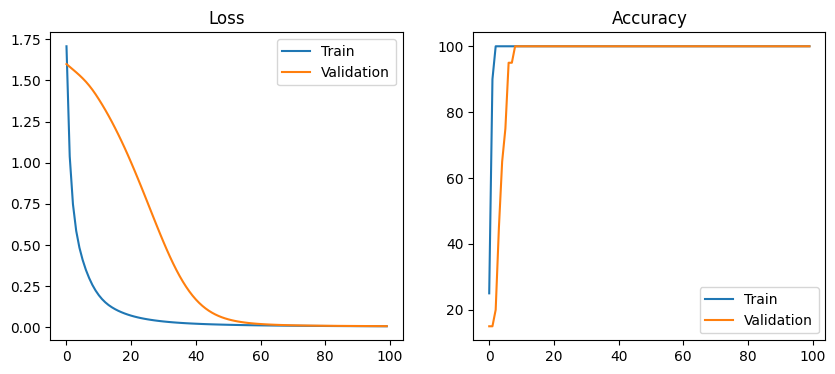

In [17]:
# 1. Grab 20 indices from the train_dataset (the warehouse, not the loader)
small_indices = range(20)
small_ds = torch.utils.data.Subset(train_ds, small_indices)

# 2. Create the loader for these 20 decks
small_loader = DataLoader(small_ds, batch_size=20)

# 3. Initialize the model with named arguments
overfit_model = EDHAttentionDeepSets(
    vocab_size=len(vocab_dict), 
    embedding_dim=EMBEDDING_SIZE, 
    hidden_dim=128, 
    pretrained_weights=pretrained_weights
).to(DEVICE)

# 4. Remove dropout for overfitting test (makes it easier to hit 100%)
overfit_model.deck_mlp[3] = nn.Identity() 

# 5. Train
history = train_net(overfit_model, small_loader, small_loader, learning_rate=0.001, num_epochs=100)
plot_training_curve(history)

### 4. Hyperparameter Search

We test different learning rates an different hidden layer sizes to find the optimal balance between model capacity and generalization.


--- Testing LR: 0.003, Hidden: 64 ---
Epoch 1: Train Acc: 20.31% | Val Acc: 20.52%
Epoch 2: Train Acc: 20.31% | Val Acc: 20.09%
Epoch 3: Train Acc: 20.63% | Val Acc: 20.63%
Epoch 4: Train Acc: 20.96% | Val Acc: 20.52%
Epoch 5: Train Acc: 20.93% | Val Acc: 20.90%
Epoch 6: Train Acc: 21.03% | Val Acc: 20.90%
Epoch 7: Train Acc: 21.16% | Val Acc: 20.88%
Epoch 8: Train Acc: 20.99% | Val Acc: 20.90%
Epoch 9: Train Acc: 21.10% | Val Acc: 20.79%
Epoch 10: Train Acc: 20.92% | Val Acc: 20.90%


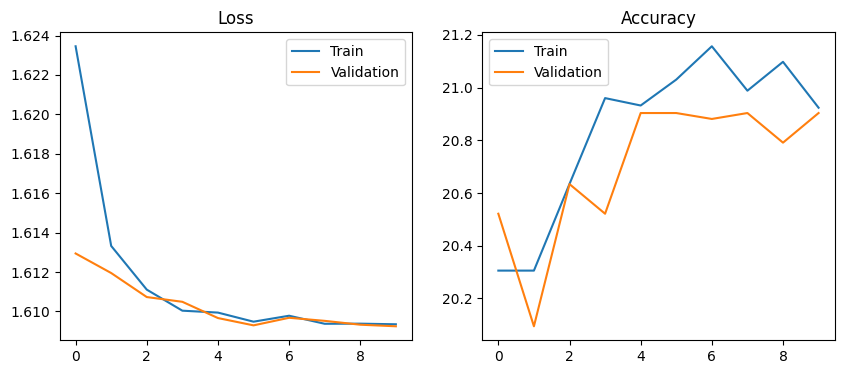


--- Testing LR: 0.003, Hidden: 128 ---
Epoch 1: Train Acc: 20.06% | Val Acc: 20.84%
Epoch 2: Train Acc: 20.56% | Val Acc: 20.84%
Epoch 3: Train Acc: 20.76% | Val Acc: 20.77%
Epoch 4: Train Acc: 20.86% | Val Acc: 20.93%
Epoch 5: Train Acc: 21.10% | Val Acc: 20.84%
Epoch 6: Train Acc: 20.95% | Val Acc: 20.77%
Epoch 7: Train Acc: 21.00% | Val Acc: 20.93%
Epoch 8: Train Acc: 21.00% | Val Acc: 20.93%
Epoch 9: Train Acc: 21.04% | Val Acc: 20.93%
Epoch 10: Train Acc: 21.04% | Val Acc: 20.84%


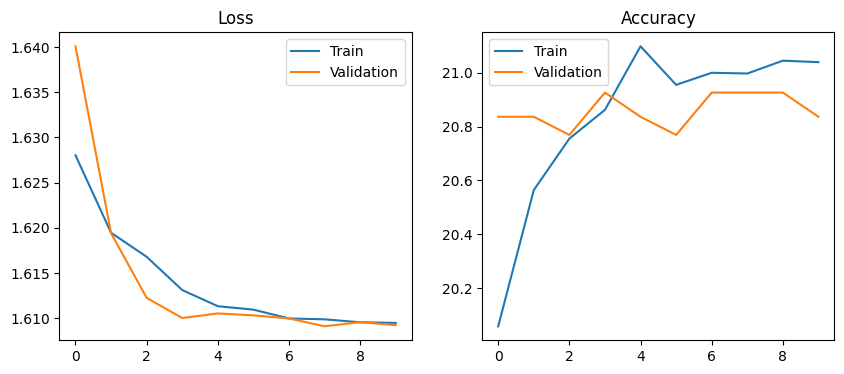


--- Testing LR: 0.003, Hidden: 256 ---
Epoch 1: Train Acc: 20.26% | Val Acc: 19.94%
Epoch 2: Train Acc: 20.40% | Val Acc: 18.86%
Epoch 3: Train Acc: 20.65% | Val Acc: 20.84%
Epoch 4: Train Acc: 20.84% | Val Acc: 20.84%
Epoch 5: Train Acc: 21.02% | Val Acc: 20.84%
Epoch 6: Train Acc: 20.89% | Val Acc: 20.77%
Epoch 7: Train Acc: 21.02% | Val Acc: 20.90%
Epoch 8: Train Acc: 20.99% | Val Acc: 20.90%
Epoch 9: Train Acc: 20.98% | Val Acc: 20.90%
Epoch 10: Train Acc: 21.03% | Val Acc: 20.90%


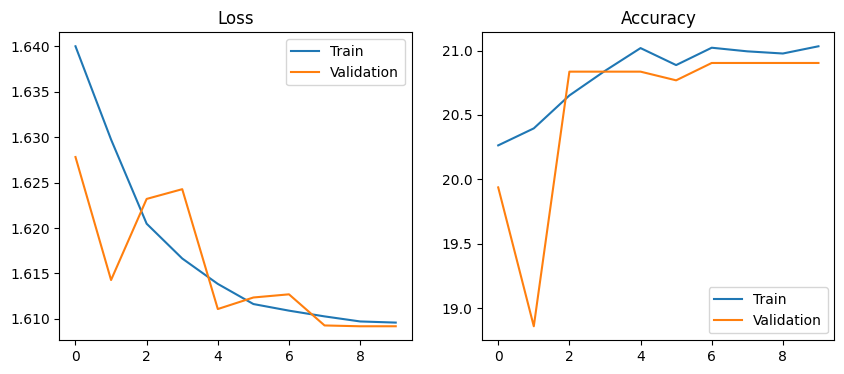


--- Testing LR: 0.001, Hidden: 64 ---
Epoch 1: Train Acc: 20.20% | Val Acc: 20.63%
Epoch 2: Train Acc: 20.38% | Val Acc: 20.34%
Epoch 3: Train Acc: 20.65% | Val Acc: 20.70%
Epoch 4: Train Acc: 20.28% | Val Acc: 20.16%
Epoch 5: Train Acc: 20.47% | Val Acc: 19.17%
Epoch 6: Train Acc: 20.67% | Val Acc: 20.23%
Epoch 7: Train Acc: 20.99% | Val Acc: 20.45%
Epoch 8: Train Acc: 20.88% | Val Acc: 20.68%
Epoch 9: Train Acc: 21.17% | Val Acc: 20.61%
Epoch 10: Train Acc: 21.56% | Val Acc: 18.99%


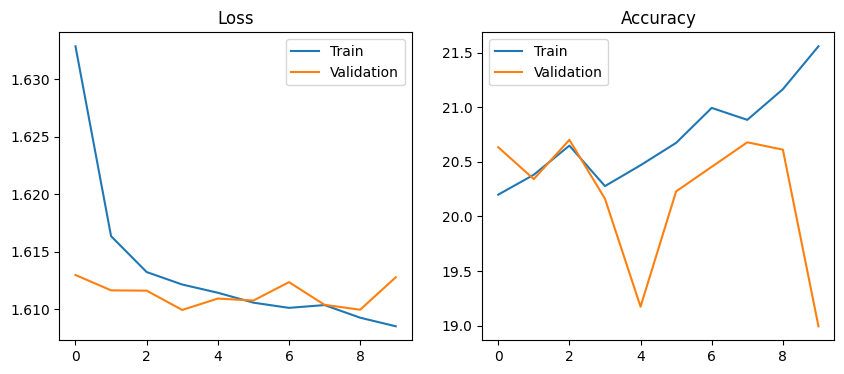


--- Testing LR: 0.001, Hidden: 128 ---
Epoch 1: Train Acc: 19.63% | Val Acc: 20.18%
Epoch 2: Train Acc: 19.85% | Val Acc: 20.68%
Epoch 3: Train Acc: 20.07% | Val Acc: 20.07%
Epoch 4: Train Acc: 20.43% | Val Acc: 20.52%
Epoch 5: Train Acc: 20.52% | Val Acc: 19.40%
Epoch 6: Train Acc: 20.54% | Val Acc: 20.07%
Epoch 7: Train Acc: 20.20% | Val Acc: 20.93%
Epoch 8: Train Acc: 20.86% | Val Acc: 20.23%
Epoch 9: Train Acc: 20.35% | Val Acc: 20.79%
Epoch 10: Train Acc: 20.45% | Val Acc: 20.45%


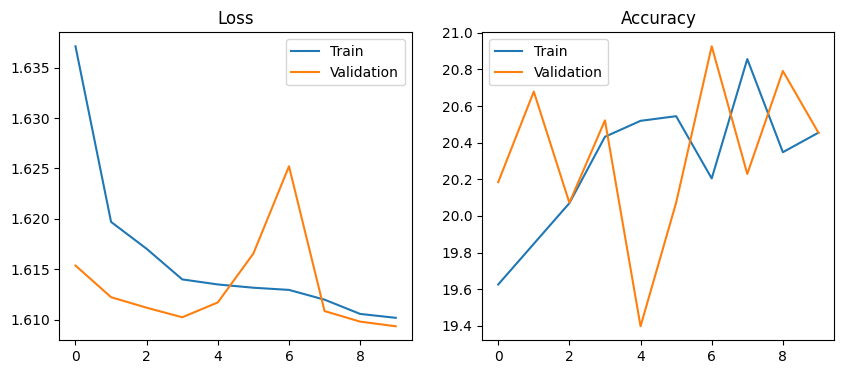


--- Testing LR: 0.001, Hidden: 256 ---
Epoch 1: Train Acc: 20.34% | Val Acc: 20.81%
Epoch 2: Train Acc: 20.40% | Val Acc: 19.64%
Epoch 3: Train Acc: 20.62% | Val Acc: 20.84%
Epoch 4: Train Acc: 20.90% | Val Acc: 20.84%
Epoch 5: Train Acc: 20.83% | Val Acc: 20.90%
Epoch 6: Train Acc: 20.85% | Val Acc: 20.90%
Epoch 7: Train Acc: 20.87% | Val Acc: 20.90%
Epoch 8: Train Acc: 20.90% | Val Acc: 20.77%
Epoch 9: Train Acc: 20.85% | Val Acc: 20.93%
Epoch 10: Train Acc: 20.95% | Val Acc: 20.90%


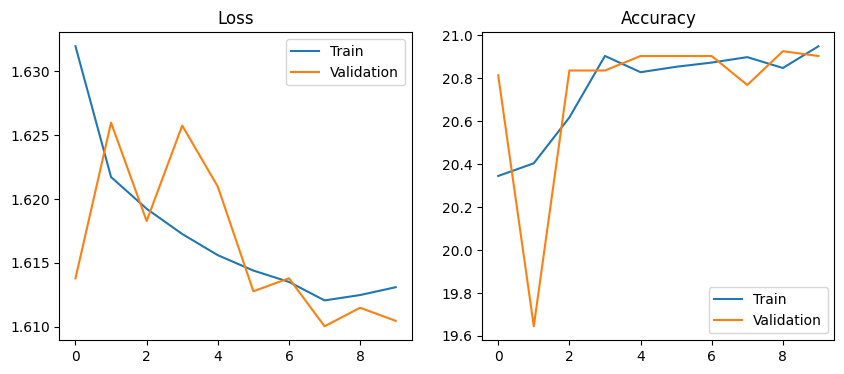


--- Testing LR: 0.0003, Hidden: 64 ---
Epoch 1: Train Acc: 19.91% | Val Acc: 20.25%
Epoch 2: Train Acc: 20.08% | Val Acc: 19.13%
Epoch 3: Train Acc: 20.45% | Val Acc: 19.02%
Epoch 4: Train Acc: 20.34% | Val Acc: 19.76%
Epoch 5: Train Acc: 20.26% | Val Acc: 19.55%
Epoch 6: Train Acc: 20.55% | Val Acc: 20.16%
Epoch 7: Train Acc: 20.20% | Val Acc: 19.58%
Epoch 8: Train Acc: 20.54% | Val Acc: 19.08%
Epoch 9: Train Acc: 21.01% | Val Acc: 20.14%
Epoch 10: Train Acc: 20.79% | Val Acc: 19.38%


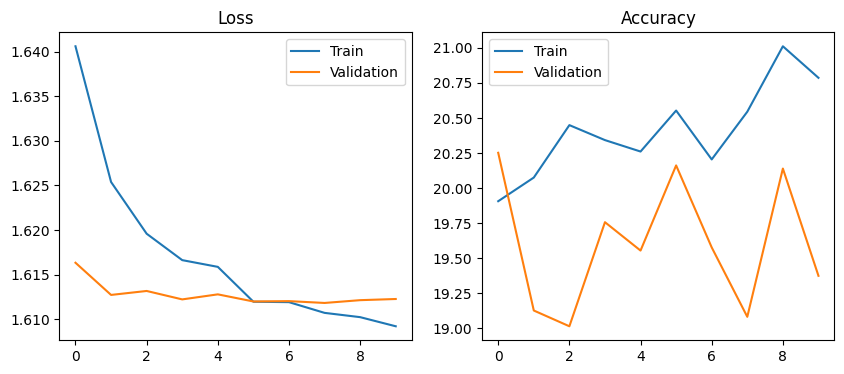


--- Testing LR: 0.0003, Hidden: 128 ---
Epoch 1: Train Acc: 19.89% | Val Acc: 20.52%
Epoch 2: Train Acc: 19.82% | Val Acc: 18.99%
Epoch 3: Train Acc: 20.44% | Val Acc: 19.91%
Epoch 4: Train Acc: 20.56% | Val Acc: 20.86%
Epoch 5: Train Acc: 20.63% | Val Acc: 20.88%
Epoch 6: Train Acc: 20.78% | Val Acc: 20.81%
Epoch 7: Train Acc: 20.71% | Val Acc: 20.81%
Epoch 8: Train Acc: 20.88% | Val Acc: 20.84%
Epoch 9: Train Acc: 20.94% | Val Acc: 18.75%
Epoch 10: Train Acc: 20.85% | Val Acc: 20.86%


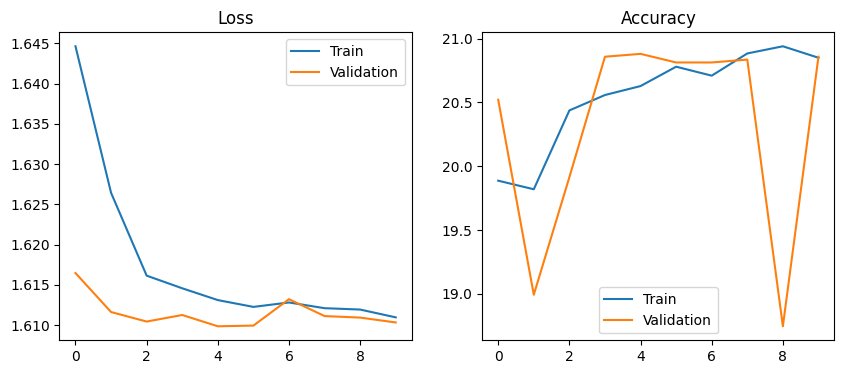


--- Testing LR: 0.0003, Hidden: 256 ---
Epoch 1: Train Acc: 19.74% | Val Acc: 20.88%
Epoch 2: Train Acc: 19.98% | Val Acc: 18.97%
Epoch 3: Train Acc: 20.75% | Val Acc: 19.24%
Epoch 4: Train Acc: 20.29% | Val Acc: 19.20%
Epoch 5: Train Acc: 20.35% | Val Acc: 20.93%
Epoch 6: Train Acc: 20.87% | Val Acc: 19.94%
Epoch 7: Train Acc: 20.26% | Val Acc: 19.64%
Epoch 8: Train Acc: 20.37% | Val Acc: 19.47%
Epoch 9: Train Acc: 21.41% | Val Acc: 19.89%
Epoch 10: Train Acc: 21.76% | Val Acc: 19.76%


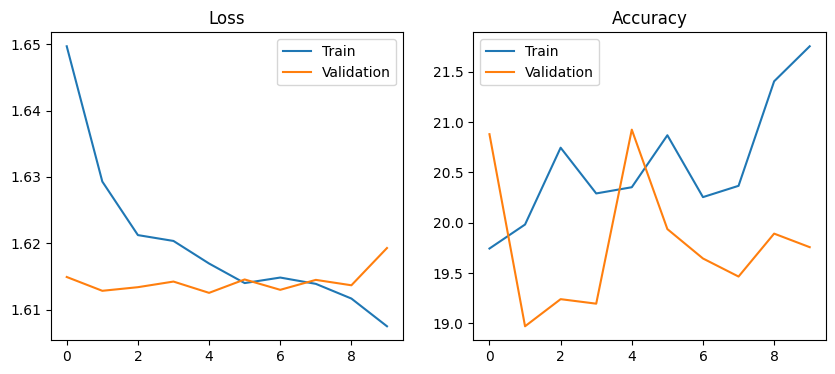

In [18]:
results = {}
for lr in [0.003, 0.001, 0.0003]:
    for hidden in [64, 128, 256]:
        print(f"\n--- Testing LR: {lr}, Hidden: {hidden} ---")
        # Now passing 'hidden' into the model
        m = EDHAttentionDeepSets(len(vocab_dict), embedding_dim=EMBEDDING_SIZE, hidden_dim=hidden, pretrained_weights=pretrained_weights)
        
        # We only run for 10 epochs to save time during the search
        h = train_net(m, train_loader, val_loader, learning_rate=lr, num_epochs=10)
        
        results[f"lr{lr}_h{hidden}"] = h
        plot_training_curve(h)

Some of these are promising. Training for more epochs:


--- Testing LR: 0.003, Hidden: 64 ---
Epoch 1: Train Acc: 20.11% | Val Acc: 19.42%
Epoch 2: Train Acc: 20.58% | Val Acc: 20.59%
Epoch 3: Train Acc: 20.40% | Val Acc: 20.16%
Epoch 4: Train Acc: 20.24% | Val Acc: 19.69%
Epoch 5: Train Acc: 20.58% | Val Acc: 20.95%
Epoch 6: Train Acc: 20.79% | Val Acc: 20.81%
Epoch 7: Train Acc: 20.75% | Val Acc: 20.84%
Epoch 8: Train Acc: 21.00% | Val Acc: 20.61%
Epoch 9: Train Acc: 20.91% | Val Acc: 20.90%
Epoch 10: Train Acc: 20.95% | Val Acc: 20.90%
Epoch 11: Train Acc: 21.01% | Val Acc: 20.90%
Epoch 12: Train Acc: 20.89% | Val Acc: 20.90%
Epoch 13: Train Acc: 21.07% | Val Acc: 20.90%
Epoch 14: Train Acc: 21.03% | Val Acc: 20.90%
Epoch 15: Train Acc: 20.90% | Val Acc: 20.90%
Epoch 16: Train Acc: 21.09% | Val Acc: 21.04%
Epoch 17: Train Acc: 21.09% | Val Acc: 20.90%
Epoch 18: Train Acc: 21.03% | Val Acc: 20.90%
Epoch 19: Train Acc: 21.10% | Val Acc: 20.90%
Epoch 20: Train Acc: 21.09% | Val Acc: 20.90%
Epoch 21: Train Acc: 21.08% | Val Acc: 20.90%
Epoc

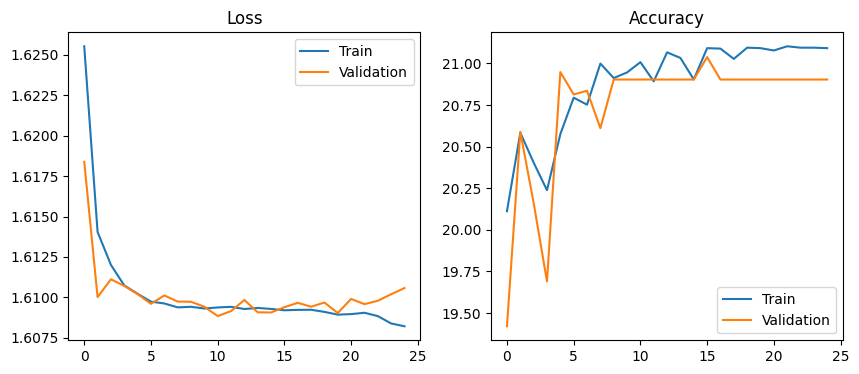


--- Testing LR: 0.001, Hidden: 128 ---
Epoch 1: Train Acc: 19.88% | Val Acc: 19.98%
Epoch 2: Train Acc: 20.26% | Val Acc: 20.48%
Epoch 3: Train Acc: 20.32% | Val Acc: 20.32%
Epoch 4: Train Acc: 20.18% | Val Acc: 20.93%
Epoch 5: Train Acc: 20.41% | Val Acc: 20.88%
Epoch 6: Train Acc: 20.56% | Val Acc: 21.20%
Epoch 7: Train Acc: 20.70% | Val Acc: 20.88%
Epoch 8: Train Acc: 21.12% | Val Acc: 20.66%
Epoch 9: Train Acc: 21.08% | Val Acc: 20.79%
Epoch 10: Train Acc: 20.98% | Val Acc: 20.90%
Epoch 11: Train Acc: 20.98% | Val Acc: 20.63%
Epoch 12: Train Acc: 21.01% | Val Acc: 20.88%
Epoch 13: Train Acc: 21.07% | Val Acc: 20.12%
Epoch 14: Train Acc: 21.33% | Val Acc: 20.43%
Epoch 15: Train Acc: 21.72% | Val Acc: 20.50%
Epoch 16: Train Acc: 22.00% | Val Acc: 20.57%
Epoch 17: Train Acc: 22.20% | Val Acc: 20.36%
Epoch 18: Train Acc: 22.59% | Val Acc: 20.14%
Epoch 19: Train Acc: 23.05% | Val Acc: 20.05%
Epoch 20: Train Acc: 23.04% | Val Acc: 19.69%
Epoch 21: Train Acc: 23.32% | Val Acc: 19.11%
Epo

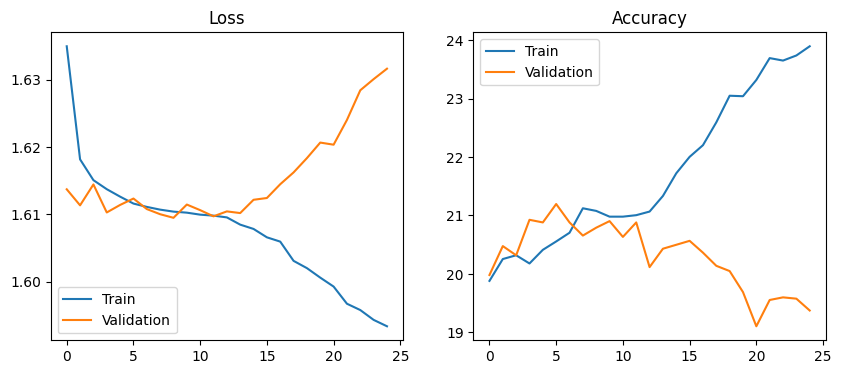


--- Testing LR: 0.0003, Hidden: 256 ---
Epoch 1: Train Acc: 19.66% | Val Acc: 19.76%
Epoch 2: Train Acc: 20.36% | Val Acc: 18.95%
Epoch 3: Train Acc: 20.53% | Val Acc: 20.63%
Epoch 4: Train Acc: 20.38% | Val Acc: 20.86%
Epoch 5: Train Acc: 20.61% | Val Acc: 19.94%
Epoch 6: Train Acc: 20.86% | Val Acc: 20.79%
Epoch 7: Train Acc: 20.61% | Val Acc: 20.84%
Epoch 8: Train Acc: 20.90% | Val Acc: 18.70%
Epoch 9: Train Acc: 20.69% | Val Acc: 20.99%
Epoch 10: Train Acc: 20.70% | Val Acc: 20.79%
Epoch 11: Train Acc: 20.87% | Val Acc: 18.81%
Epoch 12: Train Acc: 20.76% | Val Acc: 20.79%
Epoch 13: Train Acc: 20.90% | Val Acc: 20.81%
Epoch 14: Train Acc: 20.82% | Val Acc: 20.70%
Epoch 15: Train Acc: 20.83% | Val Acc: 20.84%
Epoch 16: Train Acc: 20.94% | Val Acc: 20.90%
Epoch 17: Train Acc: 20.82% | Val Acc: 20.72%
Epoch 18: Train Acc: 20.91% | Val Acc: 20.93%
Epoch 19: Train Acc: 21.05% | Val Acc: 20.97%
Epoch 20: Train Acc: 20.84% | Val Acc: 20.72%
Epoch 21: Train Acc: 20.78% | Val Acc: 20.59%
Ep

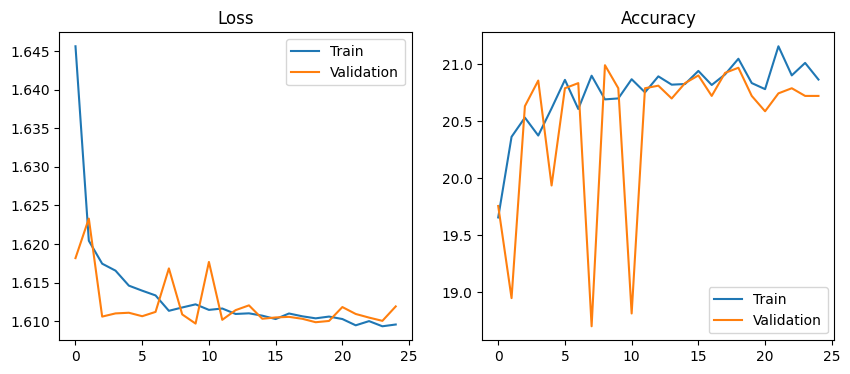

In [19]:
results = {}
for lr,hidden in [(0.003, 64), (0.001,128), (0.0003, 256)]:
    print(f"\n--- Testing LR: {lr}, Hidden: {hidden} ---")
    # Now passing 'hidden' into the model
    m = EDHAttentionDeepSets(len(vocab_dict), embedding_dim=EMBEDDING_SIZE, hidden_dim=hidden, pretrained_weights=pretrained_weights)
    
    # We only run for 10 epochs to save time during the search
    h = train_net(m, train_loader, val_loader, learning_rate=lr, num_epochs=25)
    
    results[f"lr{lr}_h{hidden}"] = h
    plot_training_curve(h)
    
    torch.save(m.state_dict(), f'lr{lr}_h{hidden}_model_weights.pth')

### 5. Model Interpretation: Visualizing Attention


To understand why the model chose a specific Bracket, we can extract the attention weights. 
High attention weights indicate "power outliers" that the model used to justify the deck's score.

In [22]:
def visualize_deck_attention(net, deck_ids, vocab, top_n=10, real_label=None):
    net.eval()
    device = next(net.parameters()).device
    inv_vocab = {v: k for k, v in vocab.items()}
    
    with torch.no_grad():
        # 1. Ensure deck_ids is a tensor and add batch dim
        if not isinstance(deck_ids, torch.Tensor):
            deck_ids = torch.tensor(deck_ids)
        x = deck_ids.unsqueeze(0).to(device) 
        
        # 2. Get mask and weights
        mask = (x != 0).float().unsqueeze(-1)
        embedded = net.embedding(x)
        card_features = net.card_mlp(embedded)
        
        attn_scores = net.attention_net(card_features)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9) # Kill padding influence
        attn_weights = F.softmax(attn_scores, dim=1) 

        # Prediction logic
        deck_vector = torch.sum(attn_weights * card_features, dim=1)
        logits = net.deck_mlp(deck_vector)
        pred_label = torch.argmax(logits, dim=1).item() + 1

    # 3. CRITICAL FIX: Filter out padding (ID 0) AND unknown tokens (ID 1)
    weights_np = attn_weights.squeeze().cpu().numpy()
    ids_np = deck_ids.cpu().numpy()
    
    # Exclude both 0 and 1 from the valid indices
    valid_indices = (ids_np != 0) & (ids_np != 1)
    clean_ids = ids_np[valid_indices]
    clean_weights = weights_np[valid_indices]
    
    # Map back to names
    card_names = [inv_vocab.get(i, f"ID:{i}") for i in clean_ids]

    # 4. Sort and Slice
    sorted_indices = np.argsort(clean_weights)[::-1][:top_n]
    top_cards = [card_names[i] for i in sorted_indices]
    top_weights = [clean_weights[i] for i in sorted_indices]

    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(top_cards, top_weights, color='teal')
    plt.xlabel("Attention Weight (Importance)")
    
    label_text = f"Predicted: Bracket {pred_label}"
    if real_label is not None:
        label_text += f" (Actual: Bracket {real_label + 1})"
    
    plt.title(label_text)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


Parsed 100 non-basic cards.


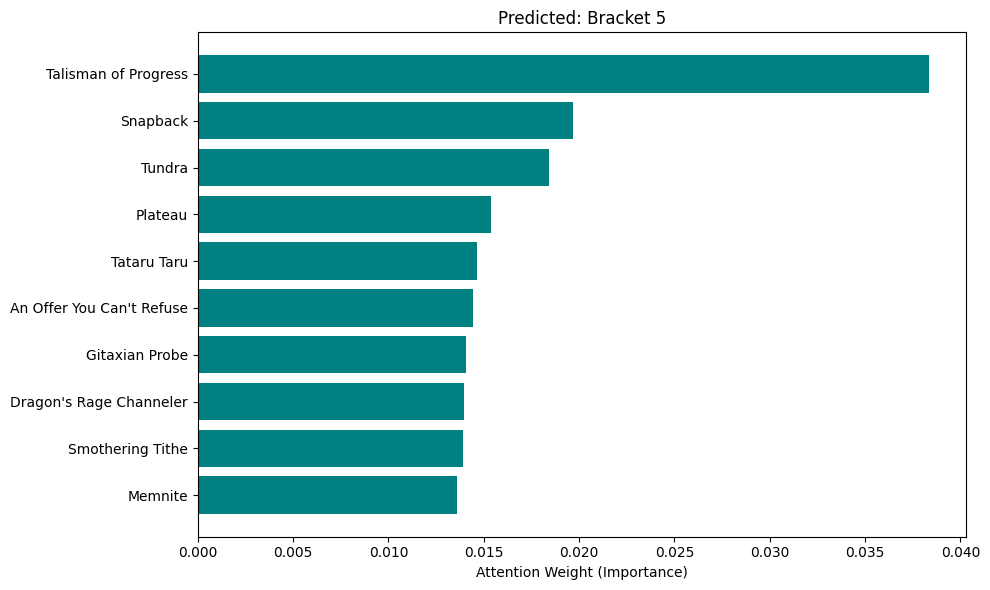

In [24]:
# Test on known decklist
# Specific decklist as a raw string
raw_deck_text = """1 Birgi, God of Storytelling
1 Dragon's Rage Channeler
1 Esper Sentinel
1 Faerie Mastermind
1 Grand Abolisher
1 Hexing Squelcher
1 Lotho, Corrupt Shirriff
1 Memnite
1 Mockingbird
1 Opposition Agent
1 Professional Face-Breaker
1 Ragavan, Nimble Pilferer
1 Ranger-Captain of Eos
1 Simian Spirit Guide
1 Tataru Taru
1 Thassa's Oracle
1 Valley Floodcaller
1 Voice of Victory
1 Arcane Signet
1 Chrome Mox
1 Lion's Eye Diamond
1 Lotus Petal
1 Mana Vault
1 Mox Amber
1 Mox Diamond
1 Mox Opal
1 Sol Ring
1 Talisman of Progress
1 Wishclaw Talisman
1 Ad Nauseam
1 An Offer You Can't Refuse
1 Borne Upon a Wind
1 Brain Freeze
1 Cabal Ritual
1 Chain of Vapor
1 Culling the Weak
1 Dark Ritual
1 Deflecting Swat
1 Demonic Consultation
1 Enlightened Tutor
1 Fierce Guardianship
1 Final Fortune
1 Flusterstorm
1 Force of Negation
1 Force of Will
1 Into the Flood Maw
1 Intuition
1 Mental Misstep
1 Mindbreak Trap
1 Mystical Tutor
1 Pact of Negation
1 Red Elemental Blast
1 Silence
1 Snapback
1 Swan Song
1 Tainted Pact
1 Vampiric Tutor
1 Beseech the Mirror
1 Demonic Tutor
1 Diabolic Intent
1 Gamble
1 Gitaxian Probe
1 Imperial Seal
1 Mnemonic Betrayal
1 Rite of Flame
1 Sevinne's Reclamation
1 Wheel of Fortune
1 Mystic Remora
1 Necropotence
1 Rhystic Study
1 Smothering Tithe
1 Underworld Breach
1 Ancient Tomb
1 Arid Mesa
1 Badlands
1 Bloodstained Mire
1 Cavern of Souls
1 City of Brass
1 City of Traitors
1 Command Tower
1 Exotic Orchard
1 Flooded Strand
1 Gemstone Caverns
1 Mana Confluence
1 Marsh Flats
1 Misty Rainforest
1 Otawara, Soaring City
1 Plateau
1 Polluted Delta
1 Scalding Tarn
1 Scrubland
1 Starting Town
1 Tundra
1 Underground Sea
1 Verdant Catacombs
1 Volcanic Island
1 Watery Grave
1 Windswept Heath
Sideboard
1 Kraum, Ludevic's Opus
1 Tymna the Weaver"""

# Processing the decklist
deck_cards = []
for line in raw_deck_text.strip().split('\n'):
    line = line.strip()
    if not line or line.lower() == 'sideboard': 
        continue
    
    # Regex to capture the number and extract just the card name
    match = re.match(r'^\d+\s+(.+)$', line)
    if match:
        card_name = match.group(1)
        if card_name not in BASIC_LANDS:
            deck_cards.append(card_name)

# Convert to Vocab IDs (using 1 for <UNK>)
max_len = 115
deck_ids = [vocab_dict.get(card, 1) for card in deck_cards]

#Pad or truncate to 115
if len(deck_ids) > max_len:
    deck_ids = deck_ids[:max_len]
else:
    deck_ids += [0] * (max_len - len(deck_ids)) 

# Convert to tensor and pass to your visualization function
custom_deck_tensor = torch.tensor(deck_ids, dtype=torch.long)

print(f"Parsed {len(deck_cards)} non-basic cards.")
# Pass None for real_label since this is a manual test without a ground truth label
visualize_deck_attention(m, custom_deck_tensor, vocab_dict, top_n=10, real_label=None)

### 6. Final Evaluation on Held-out Test Set


This represents the true performance of our best model on completely unseen data.

In [ ]:
def final_test_report(net, test_loader, criterion):
    net.eval()
    test_acc, test_loss = evaluate(net, test_loader, criterion)
    print("="*30)
    print(f"FINAL TEST ACCURACY: {test_acc*100:.2f}%")
    print(f"FINAL TEST LOSS:     {test_loss:.4f}")
    print("="*30)

In [23]:
final_test_report(m,test_loader,criterion)

FINAL TEST ACCURACY: 20.42%
FINAL TEST LOSS:     1.6139
